In [ ]:
# Variable session is nested in rat

# Consider variable rat with 2 levels: rat1 and rat2
# Consider variable session with 6 levels: rat1_session1,rat1_session2,rat1_session3 and 
#                                          rat2_session1,rat2_session2,rat2_session3
# In that case, notice that variables rat1_session1,rat1_session2,rat1_session3 belong to rat1 only,
# which means that they are nested in rat. Same for rat2 and rat2_session1,rat2_session2,rat2_session3.

# If session is an important factor of time passage and we wanna compare across sessions, we should rename it to session1, session2 and session3.
# In that case, all levels of session will appear in every level of rat:
# rat 1 - session1, session2 and session3
# rat 2 - session1, session2 and session3
# In this case, session is not nested in rat.

In [ ]:

# Here's a breakdown of the components of the model:

# Formula: The formula "ripple_cycles ~ C(shank_side, Treatment(reference='left'))" specifies the relationship between the outcome variable ripple_cycles and the predictor variable shank_side. The C() function is used to indicate that shank_side should be treated as a categorical variable. The Treatment(reference='left') part specifies that the left shank side is used as the reference category for comparison.
# Random Effects Formula (re_formula): The re_formula="1" specifies that the model includes a random intercept for each rat. This accounts for the fact that observations within the same rat may be correlated due to shared characteristics of the rat.
# Variance-Covariance Formula (vc_formula): The vc_formula={"session": "0 + session"} specifies the correlation structure between sessions. Here, we specify that the correlation between the random intercepts of sessions should be modeled using the session variable. This accounts for potential correlations between sessions within the same rat.
# Groups: The groups='rat' argument indicates that the observations are clustered within rats. This is important for estimating the random intercepts for each rat.


# import statsmodels.api as sm

# # Define the formula for the mixed-effects model
# formula = "ripple_cycles ~ C(shank_side, Treatment(reference='left'))"
# re_formula = "1"
# vc_formula = {"session": "0 + session"}
# # Fit the mixed-effects model
# model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df,groups='rat')
# result = model.fit()

# # Print summary of the model
# print(result.summary())



In [ ]:

import statsmodels.api as sm
from statsmodels.formula.api import ols

# Fit nested ANOVA model
model = ols(formula='phase_phase_coupling ~ C(side) + C(rat) + C(session)', data=df).fit()
model.summary()
# View summary of nested ANOVA
# print(model.summary())a
table = sm.stats.anova_lm(model,typ=2)

print(table)
model.summary()


In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM

# Define the formula for the mixed ANOVA model
formula = 'phase_phase_coupling ~ C(side) + C(rat) + C(session) + C(side):C(session)'

# Fit the mixed ANOVA model
model = MixedLM.from_formula(formula, data=df, groups=df['rat'])
result = model.fit()

# Print the summary of the model
print(result.summary())


In [ ]:

import pingouin as pg

model = pg.mixed_anova(data=df, dv='phase_phase_coupling', between='rat', within='side', subject='session',correction=True)
# pg.pairwise_tests(data=df, dv='ripple_abundance', between='rat', within='shank_side', subject='session', within_first=False)
model

In [12]:

import pandas as pd
import os 
import numpy as np
import matplotlib.pyplot as plt
import scipy
import seaborn as sns
import dabest

import math
import scipy.signal as sig
from scipy import stats as stats

from statsmodels.stats.proportion import proportions_chisquare
import statsmodels.api as sm
import statsmodels.formula.api as smf

%matplotlib widget


In [60]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Fit nested ANOVA model
model = ols(formula='Measurement ~ Condition', data=data).fit()

# View summary of nested ANOVA
print(model.summary())



                            OLS Regression Results                            
Dep. Variable:            Measurement   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     136.8
Date:                Fri, 12 Apr 2024   Prob (F-statistic):           1.30e-30
Time:                        14:04:58   Log-Likelihood:                -2793.5
No. Observations:                2000   AIC:                             5591.
Df Residuals:                    1998   BIC:                             5602.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.5336      0.069     -7.711      0.0

In [65]:
import statsmodels.api as sm

# Set random seed for reproducibility
np.random.seed(0)

# Define parameters
num_subjects = 20
num_sessions = 2
num_conditions = 2
num_measurements = 50

# Generate fake data
data = pd.DataFrame({
    'Subject': np.repeat(np.arange(1, num_subjects + 1), num_sessions * num_measurements),
    'Session': np.tile(np.repeat(np.arange(1, num_sessions + 1), num_measurements), num_subjects),
    'Condition': np.tile(np.tile(np.arange(1, num_conditions + 1), num_measurements), num_subjects),
    'Measurement': np.random.randn(num_subjects * num_sessions * num_measurements)
})

# Convert Session and Condition to categorical type
data['Session'] = pd.Categorical(data['Session'])
data['Condition'] = pd.Categorical(data['Condition'])
# Add some noise to create differences between conditions
data.loc[data['Condition'] == 2, 'Measurement'] += 0.5

data

,Subject,Session,Condition,Measurement
0,1,1,1,1.764052
1,1,1,2,0.900157
2,1,1,1,0.978738
3,1,1,2,2.740893
4,1,1,1,1.867558
...,...,...,...,...
1995,20,2,2,0.597751
1996,20,2,1,1.401523
1997,20,2,2,0.658434
1998,20,2,1,-1.141901


In [74]:
# Display the first few rows of the generated data
import statsmodels.api as sm

# Fit OLS model
model = sm.OLS.from_formula('Measurement ~ Session + Condition', data=data)
result = model.fit()

# Print summary
# print(result.summary())

anova_table = sm.stats.anova_lm(result, typ=2)
print(anova_table)

# Fit OLS model
model = sm.OLS.from_formula('Measurement ~ Condition', data=data)
result = model.fit()

# Print summary
# print(result.summary())
anova_table = sm.stats.anova_lm(result, typ=2)
print(anova_table)


                sum_sq      df           F        PR(>F)
Session       0.227065     1.0    0.237035  6.264096e-01
Condition   130.986613     1.0  136.737948  1.334547e-30
Residual   1913.004187  1997.0         NaN           NaN
                sum_sq      df           F        PR(>F)
Condition   130.986613     1.0  136.790183  1.300675e-30
Residual   1913.231251  1998.0         NaN           NaN


In [128]:
# Generate unique subject identifiers
import numpy as np
import pandas as pd

# Set random seed for reproducibility
np.random.seed(0)

# Define parameters
num_schools = 2
num_subjects_per_school = 30
num_sessions = 2
num_conditions = 2
num_measurements = 50

# Generate fake data
data = pd.DataFrame({
    'School': np.repeat(np.arange(1, num_schools + 1), num_subjects_per_school * num_sessions * num_conditions * num_measurements),
    'Subject': np.tile(np.repeat(np.arange(1, num_subjects_per_school + 1), num_sessions * num_conditions * num_measurements), num_schools),
    'Session': np.tile(np.repeat(np.arange(1, num_sessions + 1), num_conditions * num_measurements), num_subjects_per_school * num_schools),
    'Condition': np.tile(np.repeat(np.arange(1, num_conditions + 1), num_measurements), num_subjects_per_school * num_sessions * num_schools),
    'Measurement': np.random.randn(num_schools * num_subjects_per_school * num_sessions * num_conditions * num_measurements)
})
data.loc[data['Condition'] == 2, 'Measurement'] += 0.5

print(data.head())
# Display the first few rows of the generated data
import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = 'Measurement ~ C(Condition) + C(School) + C(Subject) + C(Session)'
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, data=data, groups=data['School'])
result = model.fit()
print(result.summary())

model = sm.OLS.from_formula(formula=formula, data=data)
result = model.fit()
print(result.summary())

anova_table = sm.stats.anova_lm(result, typ=2)
print(anova_table)


   School  Subject  Session  Condition  Measurement
0       1        1        1          1     1.764052
1       1        1        1          1     0.400157
2       1        1        1          1     0.978738
3       1        1        1          1     2.240893
4       1        1        1          1     1.867558
             Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   Measurement
No. Observations:   12000     Method:               REML       
No. Groups:         2         Scale:                0.9808     
Min. group size:    6000      Log-Likelihood:       -16966.1789
Max. group size:    6000      Converged:            Yes        
Mean group size:    6000.0                                     
---------------------------------------------------------------
                  Coef.    Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept          0.064       0.992  0.065 0.948 -1.879  2.0

In [131]:
# Define the formula for the mixed-effects model with subject as a fixed effect
formula = 'Measurement ~ C(Condition) + C(Session) + C(Subject)'

# Fit the mixed-effects model without specifying random effects
model = sm.MixedLM.from_formula(formula, data=data, groups=data['School'])
result_mixed = model.fit()

# Print the summary of the mixed-effects model
print(result_mixed.summary())

# Construct ANOVA table
anova_table_mixed = result_mixed.anova()
print(anova_table_mixed)


/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


           Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  Measurement
No. Observations:  12000    Method:              REML       
No. Groups:        2        Scale:               0.9807     
Min. group size:   6000     Log-Likelihood:      -16963.0850
Max. group size:   6000     Converged:           No         
Mean group size:   6000.0                                   
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept          0.064    0.051  1.256 0.209 -0.036  0.164
C(Condition)[T.2]  0.487    0.018 26.919 0.000  0.451  0.522
C(Session)[T.2]   -0.015    0.018 -0.808 0.419 -0.050  0.021
C(Subject)[T.2]   -0.131    0.070 -1.869 0.062 -0.268  0.006
C(Subject)[T.3]   -0.111    0.070 -1.580 0.114 -0.248  0.027
C(Subject)[T.4]   -0.106    0.070 -1.518 0.129 -0.244  0.031
C(Subject)[T.5]    0.022    0.070  0

/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2207: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2219: ConvergenceWarning: Gradient optimization failed, |grad| = 0.681844
  warnings.warn(msg, ConvergenceWarning)
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/apolo/.pyenv/versions/ripple_

AttributeError: 'MixedLMResults' object has no attribute 'anova'

In [125]:

anova_table = sm.stats.anova_lm(result, typ=1)
print(anova_table)


                   df        sum_sq     mean_sq           F         PR(>F)
C(Condition)      1.0    710.634356  710.634356  724.562545  5.326998e-155
C(School)         1.0      0.000099    0.000099    0.000101   9.919747e-01
C(Subject)       29.0     36.157062    1.246795    1.271232   1.500852e-01
C(Session)        1.0      0.640919    0.640919    0.653480   4.188871e-01
Residual      11967.0  11736.959626    0.980777         NaN            NaN


In [126]:

anova_table = sm.stats.anova_lm(result, typ=2)
print(anova_table)


                    sum_sq       df           F         PR(>F)
C(Condition)    710.634356      1.0  724.562545  5.326998e-155
C(School)         0.000099      1.0    0.000101   9.919747e-01
C(Subject)       36.157062     29.0    1.271232   1.500852e-01
C(Session)        0.640919      1.0    0.653480   4.188871e-01
Residual      11736.959626  11967.0         NaN            NaN


In [127]:

anova_table = sm.stats.anova_lm(result, typ=3)
print(anova_table)


                    sum_sq       df           F         PR(>F)
Intercept         1.503746      1.0    1.533219   2.156542e-01
C(Condition)    710.634356      1.0  724.562545  5.326998e-155
C(School)         0.000099      1.0    0.000101   9.919747e-01
C(Subject)       36.157062     29.0    1.271232   1.500852e-01
C(Session)        0.640919      1.0    0.653480   4.188871e-01
Residual      11736.959626  11967.0         NaN            NaN


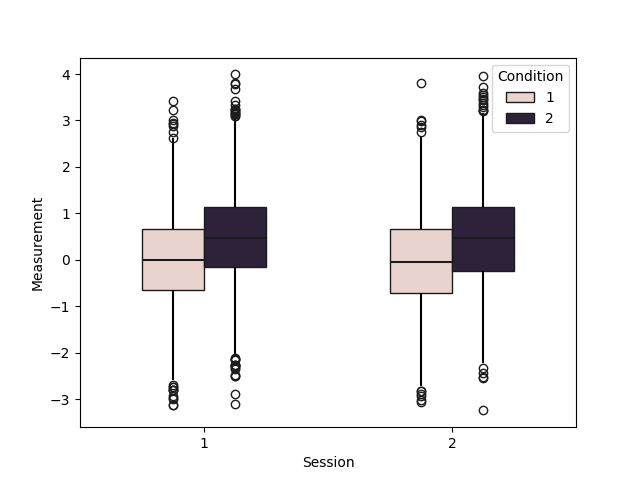

In [118]:

plt.close('all')
plt.figure()

box = sns.boxplot(data=data, x='Session',hue='Condition', y='Measurement',
            showfliers=True, showcaps=False,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5)  # Using the custom color palette
plt.show()


In [18]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
import pingouin as pg

# Generate fake data
np.random.seed(0)
n_subjects = 20
n_conditions = 2
n_measurements = 3

data = {
    'Subject': np.repeat(np.arange(1, n_subjects + 1), n_conditions * n_measurements),
    'Condition': np.tile(np.repeat(['Control', 'Drug'], n_measurements), n_subjects),
    'Time': np.tile(np.tile(np.arange(1, n_measurements + 1), n_conditions), n_subjects),
    'Outcome': np.random.normal(loc=0, scale=1, size=n_subjects * n_conditions * n_measurements)
}

df = pd.DataFrame(data)

# Analyze using statsmodels MixedLM
model_mixedlm = mixedlm("Outcome ~ Time * Condition", data=df, groups=df["Subject"])
result_mixedlm = model_mixedlm.fit()
print(result_mixedlm.summary())

# Analyze using statsmodels OLS
model_ols = sm.OLS.from_formula("Outcome ~ Time * Condition", data=df)
result_ols = model_ols.fit()
print(result_ols.summary())

# Analyze using pingouin
aov = pg.rm_anova(dv='Outcome', within='Time', subject='Subject', data=df, detailed=True)
print(aov)


              Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    Outcome  
No. Observations:     120        Method:                REML     
No. Groups:           20         Scale:                 0.9779   
Min. group size:      6          Log-Likelihood:        -176.8895
Max. group size:      6          Converged:             Yes      
Mean group size:      6.0                                        
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               0.526    0.348  1.512 0.131 -0.156  1.207
Condition[T.Drug]      -0.186    0.478 -0.390 0.697 -1.122  0.750
Time                   -0.181    0.156 -1.156 0.248 -0.487  0.126
Time:Condition[T.Drug]  0.061    0.221  0.277 0.781 -0.372  0.495
Group Var               0.137    0.108                           

                       

In [305]:
# examples taken from
# https://www.statology.org/nested-anova-in-r/
# https://www.statology.org/nested-anova-excel/
import pandas as pd
import numpy as np

# Create data
growth = [13, 16, 16, 12, 15, 16, 19, 16, 15, 15, 12, 15,
          19, 19, 20, 22, 23, 18, 16, 18, 19, 20, 21, 21,
          21, 23, 24, 22, 25, 20, 20, 22, 24, 22, 25, 26]
fertilizer = np.repeat(['A', 'B', 'C'], 12)

# this is in R (unique values for nested)
tech = np.repeat(range(1, 10), 4)

# this is in python (repeated values for nested, only way to replicate R)
tech = np.tile(np.repeat(range(1, 4), 4),3)

# Create DataFrame
df = pd.DataFrame({'growth': growth, 'fertilizer': fertilizer, 'tech': tech})
df

import statsmodels.api as sm
from statsmodels.formula.api import ols

# Fit nested ANOVA model
model = ols('growth ~ C(fertilizer) / C(tech)  ', data=df).fit()

# View summary of nested ANOVA
print(model.summary())
table = sm.stats.anova_lm(model,typ=1)
print(table)


                            OLS Regression Results                            
Dep. Variable:                 growth   R-squared:                       0.811
Model:                            OLS   Adj. R-squared:                  0.755
Method:                 Least Squares   F-statistic:                     14.45
Date:                Tue, 28 Nov 2023   Prob (F-statistic):           6.06e-08
Time:                        17:23:38   Log-Likelihood:                -68.453
No. Observations:                  36   AIC:                             154.9
Df Residuals:                      27   BIC:                             169.2
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [5]:

path = '/home/apolo/Documents/github_projects/ripple_sync/'

scripts_path = path + '/scripts/'
tables_path = path + '/tables/'
figures_path = path + '/figures/'


In [6]:

import pandas as pd
import os 
import numpy as np
import matplotlib.pyplot as plt
import scipy
import seaborn as sns

from statsmodels.stats.proportion import proportions_chisquare

%matplotlib widget


In [ ]:
'''
rat    session                shank_side

Ach 
    - Achilles_10252013     - left and right
    - Achilles_11012013     - left and right

Bud 
    - Buddy_06272013        - left and right

Cic
    - Cicero_09012014       - left and right
    - Cicero_09102014       - left and right
    - Cicero_09172014       - left and right
Gat
    - Gatsby_08022013       - left and right
    - Gatsby_08282013       - left and right


So, session is nested in rat
Let's add a new variable called session_nested to ses_1, ses_2 and ses_3

'''



In [363]:
os.chdir(tables_path + '/figure_2/')

filename = 'Figure_Ripple_Abundance_Overall.csv'
df = pd.read_csv(filename)
df


,rat,session,shank_side,shank_distance,ripple_abundance
0,Ach,Achilles_10252013,left,0.0,0.500833
1,Ach,Achilles_10252013,left,200.0,0.500000
2,Ach,Achilles_10252013,left,400.0,0.488611
3,Ach,Achilles_10252013,left,600.0,0.481111
4,Ach,Achilles_10252013,left,800.0,0.479167
...,...,...,...,...,...
103,Gat,Gatsby_08282013,right,600.0,0.466389
104,Gat,Gatsby_08282013,right,800.0,0.588056
105,Gat,Gatsby_08282013,right,1000.0,0.589444
106,Gat,Gatsby_08282013,right,1200.0,0.622500


In [364]:
unique_ses = np.unique(df['session'])
unique_ses
unique_rat = np.unique(df['rat'])
unique_rat

session_nested = df['session'].copy()
for unique_rat_label in unique_rat:
    unique_rat_label_idx = unique_rat_label == df['rat']
    
    for counter,unique_ses_label in enumerate(np.unique(df['session'][unique_rat_label_idx])):

        unique_ses_label_idx = unique_ses_label == df['session']
        session_nested_label = 'ses_' + str(counter+1)
        session_nested[unique_ses_label_idx] = session_nested_label
df.insert(2, "session_nested", session_nested)


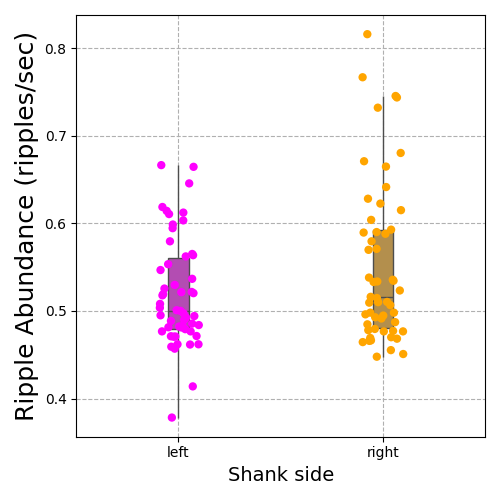

In [365]:
my_pal={"left": "magenta", "right": "orange"}

plt.close('all')
plt.figure(figsize=(5,5))
sns.stripplot(data=df, x="shank_side",hue='shank_side', y="ripple_abundance", order=["left", "right"],palette=my_pal,size=6,legend=False)
sns.boxplot(data=df,x='shank_side',hue='shank_side',y='ripple_abundance', order=["left", "right"],width=0.1,saturation=0.4,palette=my_pal,
           showcaps=False,showfliers=False)

plt.ylabel('Ripple Abundance (ripples/sec)',fontsize=18)
plt.xlabel('Shank side',fontsize=14)
plt.grid(linestyle='--')
plt.legend([], [], frameon=False)

plt.tight_layout()
plt.show()


In [366]:
import statsmodels.api as sm

model = sm.MixedLM.from_formula('ripple_abundance ~ shank_side', groups='session', data=df)
mdf = model.fit()
print(mdf.summary())


            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: ripple_abundance
No. Observations: 108     Method:             REML            
No. Groups:       8       Scale:              0.0033          
Min. group size:  12      Log-Likelihood:     139.8246        
Max. group size:  16      Converged:          Yes             
Mean group size:  13.5                                        
--------------------------------------------------------------
                     Coef. Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            0.514    0.021 24.798 0.000  0.473  0.555
shank_side[T.right]  0.031    0.011  2.852 0.004  0.010  0.053
session Var          0.003    0.031                           



/home/apolo/.pyenv/versions/3.11.6/envs/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [368]:
import pingouin as pg

pg.rm_anova(data=df, dv='ripple_abundance', within='shank_side', subject='session_nested')
pg.rm_anova(data=df, dv='ripple_abundance', within='shank_side', subject='rat')
pg.rm_anova(data=df, dv='ripple_abundance', within='shank_side', subject='session')
model = pg.mixed_anova(data=df, dv='ripple_abundance', between='rat', within='shank_side', subject='session',correction=False)

# pg.pairwise_tests(data=df, dv='ripple_abundance', between='rat', within='shank_side', subject='session', within_first=False)

model

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,rat,0.032038,3,4,0.010679,3.508686,0.128365,0.724633,NaN
1,shank_side,0.002715,1,4,0.002715,52.984035,0.001893,0.929805,1.0
2,Interaction,0.008035,3,4,0.002678,52.266966,0.001151,0.975125,NaN


In [370]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Fit nested ANOVA model
# model = ols(formula='ripple_abundance ~ C(shank_side) + C(rat) : C(session_nested)  ', data=df).fit()
model = ols(formula='ripple_abundance ~ C(shank_side) + C(rat) / C(session_nested)  ', data=df).fit()
model2 = ols(formula='ripple_abundance ~ C(shank_side) + C(rat) / C(session)  ', data=df).fit()

# View summary of nested ANOVA
# print(model.summary())
table = sm.stats.anova_lm(model,typ=1)
table2 = sm.stats.anova_lm(model2,typ=1)

print(table)
print(table2)


                            df    sum_sq   mean_sq          F        PR(>F)
C(shank_side)              1.0  0.026654  0.026654   8.129976  5.299554e-03
C(rat)                     3.0  0.227001  0.075667  23.079509  2.074403e-11
C(rat):C(session_nested)   8.0  0.097086  0.012136   3.701573  8.064882e-04
Residual                  99.0  0.324575  0.003279        NaN           NaN
                     df    sum_sq   mean_sq          F        PR(>F)
C(shank_side)       1.0  0.026654  0.026654   8.129976  5.299554e-03
C(rat)              3.0  0.227001  0.075667  23.079509  2.074403e-11
C(rat):C(session)  28.0  0.199121  0.007111   2.169099  2.786654e-03
Residual           99.0  0.324575  0.003279        NaN           NaN


In [289]:


# difference using nested (mixed) or one way anova
I_left = df['shank_side'] == 'left'
I_right = df['shank_side'] == 'right'

sessions = np.unique(df['session'])

print(np.nanmean(df['ripple_abundance'][I_left]))
print(np.nanmean(df['ripple_abundance'][I_right]))
print(np.nanmean(df['ripple_abundance'][I_right])-np.nanmean(df['ripple_abundance'][I_left]))

model = ols(formula='ripple_abundance ~ C(shank_side)', data=df).fit()
print(model.summary())


0.5138777777777778
0.5314153439153438
0.017537566137566074
                            OLS Regression Results                            
Dep. Variable:       ripple_abundance   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     1.553
Date:                Tue, 28 Nov 2023   Prob (F-statistic):              0.216
Time:                        17:15:51   Log-Likelihood:                 118.82
No. Observations:                  92   AIC:                            -233.6
Df Residuals:                      90   BIC:                            -228.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

In [290]:

I_left = df['shank_side'] == 'left'
I_right = df['shank_side'] == 'right'

rats = np.unique(df['rat'])

mean_rats_left = []
mean_rats_right = []
for rat in rats:
    I_rat = df['rat'] == rat
    mean_rats_left.append(np.nanmean(df['ripple_abundance'][I_left*I_rat]))
    mean_rats_right.append(np.nanmean(df['ripple_abundance'][I_right*I_rat]))
print(np.nanmean(mean_rats_left))
print(np.nanmean(mean_rats_right))


0.5126613375050875
0.5669839891975309


In [321]:
# difference using nested (mixed) or one way anova
I_left = df['shank_side'] == 'left'
I_right = df['shank_side'] == 'right'

sessions = np.unique(df['session'])
session_nested = np.unique(df['session_nested'])

rats = np.unique(df['rat'])

mean_rats_left = []
mean_rats_right = []
for rat in rats:
    I_rat = df['rat'] == rat
    mean_ses_left = []
    mean_ses_right = []
    session_nested = np.unique(df['session_nested'][I_rat])

    for ses in session_nested:
        I_ses = df['session_nested'] == ses
        print(rat + ' ' + ses)
        print(np.nanmean(df['ripple_abundance'][I_left*I_ses*I_rat]))
        print(np.nanmean(df['ripple_abundance'][I_right*I_ses*I_rat]))
        
    #     mean_ses_left.append(np.nanmean(df['ripple_abundance'][I_left*I_ses*I_rat]))
    #     mean_ses_right.append(np.nanmean(df['ripple_abundance'][I_right*I_ses*I_rat]))

    # mean_rats_left.append(np.nanmean(mean_ses_left))
    # mean_rats_right.append(np.nanmean(mean_ses_right))
    # print(np.nanmean(mean_ses_left))
    # print(np.nanmean(mean_ses_right))

    
        mean_ses_left.append(df['ripple_abundance'][I_left*I_ses*I_rat])
        mean_ses_right.append(df['ripple_abundance'][I_right*I_ses*I_rat])
    mean_rats_left.append(np.concatenate(mean_ses_left))
    mean_rats_right.append(np.concatenate(mean_ses_right))

model = ols(formula='ripple_abundance ~ C(shank_side) + C(rat)/C(session)', data=df).fit()
print(model.summary())


Ach ses_1
0.48685185185185187
0.50375
Ach ses_2
0.46606481481481477
0.48055555555555557
Bud ses_1
0.506031746031746
0.683888888888889
Cic ses_1
0.49824074074074076
0.4961111111111111
Cic ses_2
0.5433333333333333
0.5229166666666667
Cic ses_3
0.4873148148148147
0.4638425925925926
Gat ses_1
0.6097619047619046
0.5775
Gat ses_2
0.49874999999999997
0.6177083333333333
                            OLS Regression Results                            
Dep. Variable:       ripple_abundance   R-squared:                       0.445
Model:                            OLS   Adj. R-squared:                  0.391
Method:                 Least Squares   F-statistic:                     8.304
Date:                Tue, 28 Nov 2023   Prob (F-statistic):           3.33e-08
Time:                        17:26:21   Log-Likelihood:                 145.09
No. Observations:                  92   AIC:                            -272.2
Df Residuals:                      83   BIC:                            -249.5
Df M

In [292]:
0.4817-0.0220

0.4597

In [243]:
# difference using nested (mixed) or one way anova
I_left = df['shank_side'] == 'left'
I_right = df['shank_side'] == 'right'

sessions = np.unique(df['session'])

mean_ses_left = []
mean_ses_right = []

for ses in sessions:
    I_ses = df['session'] == ses
    print(ses)
    print(np.nanmean(df['ripple_abundance'][I_left*I_ses]))
    print(np.nanmean(df['ripple_abundance'][I_right*I_ses]))
    
    mean_ses_left.append(np.nanmean(df['ripple_abundance'][I_left*I_ses]))
    mean_ses_right.append(np.nanmean(df['ripple_abundance'][I_right*I_ses]))
# print(np.nanmean(mean_ses_left))
# print(np.nanmean(mean_ses_right))

model = ols(formula='ripple_abundance ~ C(shank_side) + C(rat)/C(session)', data=df).fit()
print(model.summary())


Achilles_10252013
0.48685185185185187
0.50375
Achilles_11012013
0.46606481481481477
0.48055555555555557
Buddy_06272013
0.5260763888888889
0.6502083333333333
Cicero_09012014
0.49824074074074076
0.4961111111111111
Cicero_09102014
0.5433333333333333
0.5229166666666667
Cicero_09172014
0.4873148148148147
0.4638425925925926
Gatsby_08022013
0.6103125
0.6513888888888889
Gatsby_08282013
0.5107638888888888
0.5686111111111111
                            OLS Regression Results                            
Dep. Variable:       ripple_abundance   R-squared:                       0.514
Model:                            OLS   Adj. R-squared:                  0.475
Method:                 Least Squares   F-statistic:                     13.09
Date:                Tue, 28 Nov 2023   Prob (F-statistic):           1.00e-12
Time:                        16:38:20   Log-Likelihood:                 160.35
No. Observations:                 108   AIC:                            -302.7
Df Residuals:               

In [197]:
# difference using nested (mixed) or one way anova
I_left = df['shank_side'] == 'left'
I_right = df['shank_side'] == 'right'

sessions = np.unique(df['session'])

mean_ses_left = []
mean_ses_right = []
for ses in sessions:
    I_ses = df['session'] == ses
    mean_ses_left.append(np.array(df['ripple_abundance'][I_left*I_ses]))
    mean_ses_right.append(np.array(df['ripple_abundance'][I_right*I_ses]))
print(np.nanmean(np.concatenate(mean_ses_left)))
print(np.nanmean(np.concatenate(mean_ses_right)))

    

0.5197788065843623
0.5511985596707819


In [205]:
from scipy import stats as stats
print(stats.sem(np.concatenate(mean_ses_left)))
print(stats.sem(np.concatenate(mean_ses_right)))


0.00839325898829282
0.012393871022824621


In [293]:
import statsmodels.api as sm

vc = {'session_nested': '0 + C(session_nested)'}

model = sm.MixedLM.from_formula('ripple_abundance ~ shank_side', vc_formula=vc,re_formula='1', groups='rat', data=df)
mdf = model.fit()
print(mdf.summary())


            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: ripple_abundance
No. Observations: 92      Method:             REML            
No. Groups:       4       Scale:              0.0028          
Min. group size:  11      Log-Likelihood:     126.7574        
Max. group size:  36      Converged:          Yes             
Mean group size:  23.0                                        
--------------------------------------------------------------
                     Coef. Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            0.519    0.024 21.247 0.000  0.471  0.566
shank_side[T.right]  0.027    0.011  2.389 0.017  0.005  0.048
rat Var              0.002    0.036                           
session_nested Var   0.001    0.011                           



/home/apolo/.pyenv/versions/3.11.6/envs/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [127]:
0.026654/0.003279

8.128697773711497

In [300]:
import pingouin as pg

pg.rm_anova(data=df, dv='ripple_abundance', within='shank_side', subject='session_nested')
pg.rm_anova(data=df, dv='ripple_abundance', within='shank_side', subject='rat')
pg.rm_anova(data=df, dv='ripple_abundance', within='shank_side', subject='session')
model = pg.mixed_anova(data=df, dv='ripple_abundance', between='rat', within='shank_side', subject='session',correction=False)

# pg.pairwise_tests(data=df, dv='ripple_abundance', between='rat', within='shank_side', subject='session', within_first=False)

model

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,rat,0.029860,3,4,0.009953,7.780446,0.038117,0.853701,NaN
1,shank_side,0.003904,1,4,0.003904,2.668609,0.177684,0.400175,1.0
2,Interaction,0.014391,3,4,0.004797,3.279141,0.140652,0.710929,NaN


In [348]:

from statsmodels.formula.api import ols
import statsmodels.api as sm

model = ols(formula="ripple_abundance ~ shank_side + session", data=df).fit()
# print(model.params)
sm.stats.anova_lm(model, typ=1)
# print(model.summary())


,df,sum_sq,mean_sq,F,PR(>F)
shank_side,1.0,0.007021,0.007021,2.534602,1.151766e-01
session,7.0,0.176989,0.025284,9.128250,2.561098e-08
Residual,83.0,0.229900,0.002770,NaN,NaN


In [70]:

from statsmodels.formula.api import ols
import statsmodels.api as sm

model = ols(formula="ripple_abundance ~ rat", data=df).fit()
# print(model.params)
# sm.stats.anova_lm(model, typ=2)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       ripple_abundance   R-squared:                       0.340
Model:                            OLS   Adj. R-squared:                  0.321
Method:                 Least Squares   F-statistic:                     17.85
Date:                Tue, 28 Nov 2023   Prob (F-statistic):           2.03e-09
Time:                        15:31:09   Log-Likelihood:                 143.81
No. Observations:                 108   AIC:                            -279.6
Df Residuals:                     104   BIC:                            -268.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4843      0.013     36.440      0.0

In [71]:
# ainda não entendi como determinar o intercept neste caso aqui

from statsmodels.formula.api import ols
import statsmodels.api as sm

model = ols(formula="ripple_abundance ~ shank_side + rat", data=df).fit()
# print(model.params)
# sm.stats.anova_lm(model, typ=2)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       ripple_abundance   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.356
Method:                 Least Squares   F-statistic:                     15.77
Date:                Tue, 28 Nov 2023   Prob (F-statistic):           4.26e-10
Time:                        15:31:38   Log-Likelihood:                 147.18
No. Observations:                 108   AIC:                            -284.4
Df Residuals:                     103   BIC:                            -270.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.4686    

In [72]:

from statsmodels.formula.api import ols
import statsmodels.api as sm

model = ols(formula="ripple_abundance ~ shank_side*rat", data=df).fit()
# print(model.params)
# sm.stats.anova_lm(model, typ=2)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       ripple_abundance   R-squared:                       0.467
Model:                            OLS   Adj. R-squared:                  0.430
Method:                 Least Squares   F-statistic:                     12.51
Date:                Tue, 28 Nov 2023   Prob (F-statistic):           2.01e-11
Time:                        15:31:49   Log-Likelihood:                 155.35
No. Observations:                 108   AIC:                            -294.7
Df Residuals:                     100   BIC:                            -273.2
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [74]:
0.0157+0.1084

0.12409999999999999

In [73]:
I_left = df['shank_side'] == 'left'
I_right = df['shank_side'] == 'right'

np.nanmean(df['ripple_abundance'][I_left])-np.nanmean(df['ripple_abundance'][I_right])
np.nanmean(df['ripple_abundance'][I_left])

0.5197788065843622

In [77]:
I_left = df['shank_side'] == 'left'
I_right = df['shank_side'] == 'right'

rat = "Ach"
I_rat = df['rat'] == rat
np.nanmean(df['ripple_abundance'][I_rat*I_left])
np.nanmean(df['ripple_abundance'][I_rat*I_right])
np.nanmean(df['ripple_abundance'][I_rat*I_right])-np.nanmean(df['ripple_abundance'][I_rat*I_left])

0.015694444444444344

In [224]:
I_left = df['shank_side'] == 'left'
I_right = df['shank_side'] == 'right'

rat = "Bud"
I_rat = df['rat'] == rat
np.nanmean(df['ripple_abundance'][I_rat*I_left])
np.nanmean(df['ripple_abundance'][I_rat*I_right])
# np.nanmean(df['ripple_abundance'][I_rat*I_right])-np.nanmean(df['ripple_abundance'][I_rat*I_left])

0.6502083333333333

In [222]:
# pd.get_dummies(df,drop_first=True) 
0.6502083333333333-0.5260763888888889

0.12413194444444442

In [211]:
I_left = df['shank_side'] == 'left'
I_right = df['shank_side'] == 'right'

ses = "Achilles_10252013"
I_ses = df['session'] == ses
np.nanmean(df['ripple_abundance'][I_ses*I_left])
# np.nanmean(df['ripple_abundance'][I_ses*I_right])


0.48685185185185187

In [78]:
# difference using nested (mixed) or one way anova
I_left = df['shank_side'] == 'left'
I_right = df['shank_side'] == 'right'

sessions = np.unique(df['session'])

for ses in sessions:
    I_ses = df['session'] == ses
    print(ses)
    print(np.nanmean(df['ripple_abundance'][I_ses]))
    print(np.nanmean(df['ripple_abundance'][I_left*I_ses]))
    print(np.nanmean(df['ripple_abundance'][I_right*I_ses]))
    print()
    

Achilles_10252013
0.49530092592592584
0.48685185185185187
0.50375

Achilles_11012013
0.47331018518518514
0.46606481481481477
0.48055555555555557

Buddy_06272013
0.5881423611111112
0.5260763888888889
0.6502083333333333

Cicero_09012014
0.4971759259259259
0.49824074074074076
0.4961111111111111

Cicero_09102014
0.533125
0.5433333333333333
0.5229166666666667

Cicero_09172014
0.47557870370370364
0.4873148148148147
0.4638425925925926

Gatsby_08022013
0.6308506944444445
0.6103125
0.6513888888888889

Gatsby_08282013
0.5396874999999999
0.5107638888888888
0.5686111111111111



In [107]:
# difference using nested (mixed) or one way anova
I_left = df['shank_side'] == 'left'
I_right = df['shank_side'] == 'right'

sessions = np.unique(df['session'])
left_mean = []
right_mean = []

for ses in sessions:
    I_ses = df['session'] == ses
    
    left_mean.append(np.nanmean(df['ripple_abundance'][I_left*I_ses]))
    right_mean.append(np.nanmean(df['ripple_abundance'][I_right*I_ses]))
left_mean = np.array(left_mean)
right_mean = np.array(right_mean)

# nested
print('Nested')
print(np.nanmean(left_mean))
print(np.nanmean(right_mean))
print(np.nanmean(right_mean)-np.nanmean(left_mean))
print()
print()


Nested
0.5161197916666667
0.5421730324074074
0.02605324074074078




In [110]:
left_mean

array([0.48685185, 0.46606481, 0.52607639, 0.49824074, 0.54333333,
       0.48731481, 0.6103125 , 0.51076389])

In [6]:
import statsmodels.api as sm

import statsmodels.formula.api as smf

data = sm.datasets.get_rdataset("dietox", "geepack").data

md = smf.mixedlm("Weight ~ Time", data, groups=data["Pig"])

mdf = md.fit()

print(mdf.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Weight    
No. Observations: 861     Method:             REML      
No. Groups:       72      Scale:              11.3669   
Min. group size:  11      Log-Likelihood:     -2404.7753
Max. group size:  12      Converged:          Yes       
Mean group size:  12.0                                  
--------------------------------------------------------
             Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept    15.724    0.788  19.952 0.000 14.179 17.268
Time          6.943    0.033 207.939 0.000  6.877  7.008
Group Var    40.394    2.149                            



In [73]:

import statsmodels.api as sm
import statsmodels.formula.api as smf

md = smf.mixedlm("ripple_abundance ~ shank_side", data=df, groups=df["session"], re_formula="~shank_side")
mdf = md.fit(method=["lbfgs"])
print(mdf.summary())


                  Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    ripple_abundance
No. Observations:      108        Method:                REML            
No. Groups:            8          Scale:                 0.0029          
Min. group size:       12         Log-Likelihood:        144.2808        
Max. group size:       16         Converged:             Yes             
Mean group size:       13.5                                              
-------------------------------------------------------------------------
                                Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                       0.516    0.016 31.785 0.000  0.484  0.548
shank_side[T.right]             0.027    0.018  1.532 0.126 -0.008  0.062
Group Var                       0.002    0.021                           
Group x shank_side[T.right] Cov 0.001    0.016          

/home/apolo/.pyenv/versions/information_Metrics/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [65]:
# difference using nested (mixed) or one way anova
I_left = df['shank_side'] == 'left'
I_right = df['shank_side'] == 'right'

sessions = np.unique(df['session'])
left_mean = []
right_mean = []

for ses in sessions:
    I_ses = df['session'] == ses
    left_mean.append(np.nanmean(df['ripple_abundance'][I_left*I_ses]))
    right_mean.append(np.nanmean(df['ripple_abundance'][I_right*I_ses]))
left_mean = np.array(left_mean)
right_mean = np.array(right_mean)

# nested
print('Nested')
print(np.nanmean(left_mean))
print(np.nanmean(right_mean))
print(np.nanmean(right_mean)-np.nanmean(left_mean))
print()
print()
# anova 
print('Non Nested')
print(np.nanmean(df['ripple_abundance'][I_left]))
print(np.nanmean(df['ripple_abundance'][I_right]))
print(np.nanmean(df['ripple_abundance'][I_right])-np.nanmean(df['ripple_abundance'][I_left]))


Nested
0.5161197916666667
0.5421730324074074
0.02605324074074078


Non Nested
0.5197788065843622
0.5511985596707819
0.031419753086419755


In [31]:
import pingouin as pg

In [38]:
# mixed_model = pg.mixed_anova(dv='ripple_abundance', between='session', subject='session',within = 'shank_side', data=df)

mixed_model = pg.rm_anova(data=df, dv='ripple_abundance', within='shank_side', subject='session')
mixed_model


,Source,ddof1,ddof2,F,p-unc,ng2,eps
0,shank_side,1,7,2.306506,0.172629,0.049216,1.0


In [40]:
# Holm-corrected pairwise T-tests
pg.pairwise_tests(data=df, dv='ripple_abundance', within='shank_side', subject='session', return_desc=True, padjust='holm')


,Contrast,A,B,mean(A),std(A),mean(B),std(B),Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,shank_side,left,right,0.51612,0.045122,0.542173,0.073872,True,True,-1.518719,7.0,two-sided,0.172629,0.782,-0.402425
